In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pyspark.sql.functions import rand

spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("UK Police") \
    .getOrCreate()

sc = spark.sparkContext

sc._jvm.org.apache.log4j.Logger.getLogger("org.apache.spark.scheduler.TaskSetManager").setLevel(
    spark.sparkContext._jvm.org.apache.log4j.Level.ERROR
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/10 21:21:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
df_final = spark.read.parquet("data/processed_data.parquet").cache()

# Models training

In [3]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml import Pipeline
from dateutil.relativedelta import relativedelta
import time

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array
import shap
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import rand

# import logging
# import warnings

# warnings.filterwarnings('ignore')
# logging.getLogger('py4j').setLevel(logging.ERROR)

In [4]:
categorical_cols = ["age", "gender", "law", "ethnicity", "search_type", "reason", "police_force"]
numeric_cols = ["hour", "month", "dayofweek", "dayofyear"]
feature_cols = [f"{col}_idx" for col in categorical_cols] + numeric_cols

In [5]:
def train_dt(
    train_df,
    categorical_cols,
    numeric_cols,
    feature_cols
):
    # 1) Weight model
    class_counts = train_df.groupBy("legal_action_taken").count().collect()

    neg_count = [x['count'] for x in class_counts if x['legal_action_taken'] == 0][0]
    pos_count = [x['count'] for x in class_counts if x['legal_action_taken'] == 1][0]
    weight_ratio = neg_count / (neg_count+pos_count)
    
    print(f" Unbalance: {neg_count:,} ({weight_ratio*100:.2f}%) negatives vs {pos_count:,} ({(1-weight_ratio)*100:.2f}%) positives")
    print()

    weighted_df= train_df.withColumn(
        "classWeight",
        F.when(F.col("legal_action_taken") == 1, weight_ratio).otherwise(1.0-weight_ratio)
    )

    # 2. String Indexers
    indexers = [
        StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep") 
        for col in categorical_cols
    ]
    
    # 3. Vector Assembler
    assembler = VectorAssembler(
        inputCols=feature_cols, 
        outputCol="features",
        handleInvalid="keep"
    )
    
    # 4. Decision Tree Estimator
    dt = DecisionTreeClassifier(
        labelCol="legal_action_taken", 
        featuresCol="features", 
        weightCol="classWeight",
        maxDepth=10, 
        maxBins=128,
        minInstancesPerNode=5,
        impurity="gini",
        seed=42
    )
    
    # 5. Construct the Pipeline
    pipeline = Pipeline(stages=indexers + [assembler, dt])
    
    # 6. Evaluator
    evaluator = BinaryClassificationEvaluator(
        rawPredictionCol='rawPrediction',  
        labelCol='legal_action_taken',
        metricName="areaUnderPR"
    )
    
    # 7. Fit with error handling
    try:
        print("Starting Pipeline Training...")
        start_time = time.time()
        
        # This will call your custom _kFold logic internally
        trained_pipeline = pipeline.fit(weighted_df)
        
        total_time = time.time() - start_time
        print(f"Pipeline fitting complete. Total time: {total_time:.2f} seconds.")
        
    except Exception as e:
        print(f"Error during fitting: {e}")
        # Additional debugging
        print("\nDataset sample:")
        df_final.select("legal_action_taken", "timestamp", *categorical_cols[:3]).show(5)
        raise
        
    transformed_df = trained_pipeline.transform(weighted_df)
    
    return trained_pipeline, neg_count, pos_count, transformed_df

In [6]:
def show_importances(
    year,
    trained_pipeline,
    categorical_cols,
    numeric_cols,
    feature_cols,
    transformed_df,
    sample_size=500
):
    
    # Extract the model from the pipeline
    dt_model = trained_pipeline.stages[-1]
    
    # ========== FEATURE IMPORTANCES ==========
    feature_importances = dt_model.featureImportances.toArray()
    
    # Get feature names
    readable_names = [col.replace('_idx', '') for col in feature_cols]
    
    importance_df = pd.DataFrame({
        'Feature': readable_names,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)
    
    # ========== PREPARE DATA FOR SHAP ANALYSIS ==========
    print(f"Getting a set of {sample_size} samples for the SHAP...")

    # Take 50% of class 0 and 50% of class 1 
    count_0 = transformed_df.filter(F.col("legal_action_taken") == 0).count()
    count_1 = transformed_df.filter(F.col("legal_action_taken") == 1).count()

    half_size = sample_size // 2
    
    fraction_0 = half_size / count_0
    fraction_1 = half_size / count_1
    
    sample_0 = transformed_df.filter(F.col("legal_action_taken") == 0).sample(
        withReplacement=False, 
        fraction=fraction_0,
        seed=42
    ).limit(half_size)
    
    sample_1 = transformed_df.filter(F.col("legal_action_taken") == 1).sample(
        withReplacement=False, 
        fraction=fraction_0,
        seed=42
    ).limit(half_size)
    
    # Join samples of class 0 and class 1
    sample_df = sample_0.union(sample_1).toPandas() 
    
    # Extract features as numpy array
    X_sample = np.array([row.toArray() for row in sample_df['features']])
    
    # Function for predicting with SHAP
    def predict_fn(X):
        from pyspark.ml.linalg import Vectors
        from pyspark.sql import SparkSession
        
        spark = SparkSession.builder.getOrCreate()
        
        # Convert to Spark format
        spark_data = [(Vectors.dense(row),) for row in X]
        temp_df = spark.createDataFrame(spark_data, ["features"])
        
        # Predict only with the DT model
        predictions = dt_model.transform(temp_df)
        
        # Return the probability of the class 1
        return np.array([row.probability[1] for row in predictions.select("probability").collect()])
    
    # ========== CALCULATE SHAP VALUES ==========
    print("Calculating SHAP values...")
    
    # Use a smaller sample as background for the KernelExplainer
    background_size = min(100, sample_size // 2)
    explainer = shap.KernelExplainer(predict_fn, X_sample[:background_size])
    
    # Calculate SHAP values
    shap_sample_size = min(200, sample_size)
    shap_values = explainer.shap_values(X_sample[:shap_sample_size])

    # Save cvs
    importance_df.to_csv(f'media/results/police_behaviour_over_years/feature_importance_{year}.csv', index=False)
    
    # ========== Show Figures ==========
    year = 2023
    
    # Calculate parameters
    top_n = min(15, len(importance_df))
    
    fig = plt.figure(figsize=(18, 6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.3], wspace=0.25, hspace=0.3) 
    
    # Subplot 1: Feature Importance (DT)
    ax1 = fig.add_subplot(gs[0, 0])
    sns.barplot(
        data=importance_df.head(top_n), 
        x="Importance", 
        y="Feature", 
        hue="Feature",   
        palette="viridis", 
        legend=False,
        ax=ax1
    )
    ax1.set_xlabel('Importance', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Feature', fontsize=13, fontweight='bold')
    ax1.set_title('Feature Importance - Decision Tree', 
                  fontsize=15, fontweight='bold', pad=15)
    ax1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)
    ax1.tick_params(axis='both', labelsize=11)
    
    # Subplot 2: SHAP Summary Plot
    ax2 = fig.add_subplot(gs[0, 1])
    plt.sca(ax2)
    shap.summary_plot(
        shap_values, 
        X_sample[:shap_sample_size],
        feature_names=readable_names,
        show=False,
        max_display=top_n,
        plot_size=None
    )
    ax2.set_title('SHAP Feature Impact Analysis', 
                  fontsize=15, fontweight='bold', pad=15)
    ax2.set_xlabel('SHAP value (impact on model output)', 
                   fontsize=12, fontweight='bold')
    ax2.tick_params(axis='both', labelsize=11)
    
    # Close Box
    ax2.spines['top'].set_visible(True)
    ax2.spines['left'].set_visible(True)
    ax2.spines['right'].set_visible(True)
    
    ax2.spines['top'].set_linewidth(0.8)
    ax2.spines['left'].set_linewidth(0.8)
    ax2.spines['right'].set_linewidth(0.8)
    
    # Adjust space
    plt.subplots_adjust(top=0.95, bottom=0.2)
    
    # Save figure
    plt.savefig(f"media/images/police_behaviour_over_years/feature_importance_with_shap_{year}.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

# Finding Optimal Threshold

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pyspark.sql import functions as F
from pyspark.sql.functions import rand
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, DoubleType

# UDF para convertir vector a array
vector_to_array = udf(lambda v: v.toArray().tolist(), ArrayType(DoubleType()))


def find_optimal_threshold(
    predictions_df, 
    start=0.5, 
    end=1.0, 
    step=0.035,
    optimization_metric='min_recall_difference',
    year = 2023
):
    
    thresholds = np.arange(start, end + step, step)
    results = {
        'thresholds': [],
        'f1_scores': [],
        'accuracies': [],
        'precisions': [],
        'recalls': [],
        'balanced_accuracies': [],
        'geometric_means': [],
        'sensitivity_class0': [],  # Recall for class 0 (TN rate)
        'sensitivity_class1': [],  # Recall for class 1 (TP rate)
        'recall_differences': [],  # Absolute Differences between recalls
    }
    
    evaluator = MulticlassClassificationEvaluator(
        labelCol="legal_action_taken",
        predictionCol="threshold_prediction"
    )
    
    print(f"* Evaluating {len(thresholds)} thresholds from {start} to {end}...")
    print(f"* Optimization metric: {optimization_metric}")
    
    for threshold in thresholds:
        # Create prediction with actual threshold
        temp_predictions = predictions_df.withColumn(
            "threshold_prediction",
            F.when(F.col("prob_array")[1] >= threshold, F.lit(1.0))
             .otherwise(F.lit(0.0))
             .cast("double")
        )
        
        # Calculate global metrics
        f1 = evaluator.evaluate(
            temp_predictions,
            {evaluator.metricName: "f1"}
        )
        
        accuracy = evaluator.evaluate(
            temp_predictions,
            {evaluator.metricName: "accuracy"}
        )
        
        precision = evaluator.evaluate(
            temp_predictions,
            {evaluator.metricName: "weightedPrecision"}
        )
        
        recall = evaluator.evaluate(
            temp_predictions,
            {evaluator.metricName: "weightedRecall"}
        )
        
        # Calculate metrics per class
        # Class 0
        tn = temp_predictions.filter(
            (F.col("legal_action_taken") == 0) & 
            (F.col("threshold_prediction") == 0.0)
        ).count()
        
        fp = temp_predictions.filter(
            (F.col("legal_action_taken") == 0) & 
            (F.col("threshold_prediction") == 1.0)
        ).count()
        
        # Class 1
        tp = temp_predictions.filter(
            (F.col("legal_action_taken") == 1) & 
            (F.col("threshold_prediction") == 1.0)
        ).count()
        
        fn = temp_predictions.filter(
            (F.col("legal_action_taken") == 1) & 
            (F.col("threshold_prediction") == 0.0)
        ).count()
        
        # Sensitivity (Recall) per class
        sensitivity_class0 = tn / (tn + fp) if (tn + fp) > 0 else 0  # Specificity = TN rate
        sensitivity_class1 = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity = TP rate
        
        # Balanced Accuracy: mean recall
        balanced_acc = (sensitivity_class0 + sensitivity_class1) / 2
        
        # Geometric Mean
        geometric_mean = np.sqrt(sensitivity_class0 * sensitivity_class1)
        
        # Absolut Difference between recalls (We want to minimaze this)
        recall_diff = abs(sensitivity_class0 - sensitivity_class1)
        
        # Save Results
        results['thresholds'].append(threshold)
        results['f1_scores'].append(f1)
        results['accuracies'].append(accuracy)
        results['precisions'].append(precision)
        results['recalls'].append(recall)
        results['balanced_accuracies'].append(balanced_acc)
        results['geometric_means'].append(geometric_mean)
        results['sensitivity_class0'].append(sensitivity_class0)
        results['sensitivity_class1'].append(sensitivity_class1)
        results['recall_differences'].append(recall_diff)
    
    # Find optimal threshold based on metric
    if optimization_metric == 'min_recall_difference':
        metric_values = results['recall_differences']
        max_metric_idx = np.argmin(metric_values)  
        metric_name = 'Recall Difference (minimized)'
    elif optimization_metric == 'balanced_accuracy':
        metric_values = results['balanced_accuracies']
        max_metric_idx = np.argmax(metric_values)
        metric_name = 'Balanced Accuracy'
    elif optimization_metric == 'geometric_mean':
        metric_values = results['geometric_means']
        max_metric_idx = np.argmax(metric_values)
        metric_name = 'Geometric Mean'
    else:  # f1
        metric_values = results['f1_scores']
        max_metric_idx = np.argmax(metric_values)
        metric_name = 'F1 Score'
    
    optimal_threshold = results['thresholds'][max_metric_idx]
    optimal_metric_value = metric_values[max_metric_idx]
    
    # Visualize results
    plot_threshold_analysis(results, optimal_threshold, optimal_metric_value, 
                           optimization_metric, metric_name, year)
    
    return optimal_threshold, optimal_metric_value, results


def plot_threshold_analysis(
    results, 
    optimal_threshold, 
    optimal_metric_value, 
    optimization_metric, 
    metric_name, 
    year
):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Figure 1: Optimization metric vs Threshold
    ax1 = axes[0]
    
    if optimization_metric == 'balanced_accuracy':
        metric_values = results['balanced_accuracies']
        color = 'purple'
    elif optimization_metric == 'geometric_mean':
        metric_values = results['geometric_means']
        color = 'darkgreen'
    else:
        metric_values = results['f1_scores']
        color = 'blue'
    
    ax1.plot(results['thresholds'], results['sensitivity_class0'], 
             'b-', linewidth=2.5, label='Class 0 Recall (Specificity)', marker='o', markersize=4)
    ax1.plot(results['thresholds'], results['sensitivity_class1'], 
             'r-', linewidth=2.5, label='Class 1 Recall (Sensitivity)', marker='s', markersize=4)
    ax1.plot(results['thresholds'], results['recall_differences'], 
             'orange', linewidth=2.5, label='|Difference| (lower = more balanced)', 
             marker='x', markersize=5, linestyle=':')
    ax1.axvline(x=optimal_threshold, color='green', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'Optimal Threshold')
    
    # Mark the point where threshold is selected
    opt_idx = results['thresholds'].index(optimal_threshold)
    ax1.scatter([optimal_threshold, optimal_threshold], 
                [results['sensitivity_class0'][opt_idx], results['sensitivity_class1'][opt_idx]], 
                color='green', s=100, zorder=5, edgecolors='black', linewidth=2)
    
    ax1.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_title('Class Balance: Recall per Class vs Threshold', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best', fontsize=10)
    ax1.set_ylim([0, 1.05])
    
    # Figure 2: Global metrics vs threshold
    ax2 = axes[1]
    ax2.plot(results['thresholds'], results['f1_scores'], 
             'b-', linewidth=2, label='F1 Score', marker='o', markersize=3)
    ax2.plot(results['thresholds'], results['accuracies'], 
             'g-', linewidth=2, label='Accuracy', marker='s', markersize=3)
    ax2.plot(results['thresholds'], results['balanced_accuracies'], 
             'purple', linewidth=2, label='Balanced Accuracy', marker='D', markersize=3)
    ax2.plot(results['thresholds'], results['geometric_means'], 
             'darkgreen', linewidth=2, label='Geometric Mean', marker='*', markersize=5)
    ax2.axvline(x=optimal_threshold, color='red', linestyle='--', 
                linewidth=2, alpha=0.7)
    
    ax2.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax2.set_title('All Metrics vs Threshold', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='best', fontsize=9)
    ax2.set_ylim([0, 1.05])
    
    plt.tight_layout()
    plt.savefig(f"media/images/police_behaviour_over_years/optim_threshold_{year}.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Imprimir resumen
    print("\n" + "="*70)
    print("THRESHOLD OPTIMIZATION RESULTS")
    print("="*70)
    print(f"Optimization Metric: {metric_name}")
    print(f"Optimal Threshold:   {optimal_threshold:.4f}")
    
    if optimization_metric == 'min_recall_difference':
        print(f"Minimum Recall Difference: {optimal_metric_value:.4f}")
    else:
        print(f"Maximum {metric_name}: {optimal_metric_value:.4f}")
    
    opt_idx = results['thresholds'].index(optimal_threshold)
    print(f"\n{'='*70}")
    print("ALL METRICS AT OPTIMAL THRESHOLD:")
    print("="*70)
    print(f"  Accuracy:           {results['accuracies'][opt_idx]:.4f}")
    print(f"  Balanced Accuracy:  {results['balanced_accuracies'][opt_idx]:.4f}")
    print(f"  Geometric Mean:     {results['geometric_means'][opt_idx]:.4f}")
    print(f"  F1 Score:           {results['f1_scores'][opt_idx]:.4f}")
    print(f"  Precision: {results['precisions'][opt_idx]:.4f}")
    print(f"  Recall:    {results['recalls'][opt_idx]:.4f}")
    print(f"\n  Class 0 Recall (Specificity): {results['sensitivity_class0'][opt_idx]:.4f}")
    print(f"  Class 1 Recall (Sensitivity): {results['sensitivity_class1'][opt_idx]:.4f}")
    print(f"  Recall Difference:            {results['recall_differences'][opt_idx]:.4f}")
    print("="*70 + "\n")


def calculate_metrics(
    year,
    trained_pipeline,
    test_df,
    neg_count,
    pos_count,
    threshold=None,
    optimize_threshold=True,
    optimization_metric='min_recall_difference'
):
    
    total = neg_count + pos_count
    neg_p = neg_count / total
    pos_p = pos_count / total
    
    # =====================================================
    # 1. Dataset size
    # =====================================================
    print(f"Test data size: {test_df.count()}")

    # =====================================================
    # 2. Predictions via pipeline
    # =====================================================
    predictions = trained_pipeline.transform(test_df)

    # =====================================================
    # 3. Preparate probabilities (CACHED if possible)
    # =====================================================
    predictions = (
        predictions
        .withColumn(
            "prob_array",
            vector_to_array(F.col("probability"))
        )
    )
    
    predictions.cache()
    predictions.count()  # Force usage of cache
    
    # =====================================================
    # 4. OPTIMIZE THRESHOLD
    # =====================================================
    if optimize_threshold and threshold is None:
        print(f"\nOptimizing threshold based on '{optimization_metric}':")
        optimal_threshold, max_metric_value, threshold_results = find_optimal_threshold(
            predictions, 
            start=0.5, 
            end=1.0, 
            step=0.035,
            optimization_metric=optimization_metric,
            year=year
        )
        threshold = optimal_threshold
    elif threshold is None:
        threshold = 0.5
        print(f"\nUsing default threshold: {threshold}")
    else:
        print(f"\nUsing provided threshold: {threshold}")
    
    # =====================================================
    # 5. Use final threshold
    # =====================================================
    predictions = predictions.withColumn(
        "custom_prediction",
        F.when(F.col("prob_array")[1] >= threshold, F.lit(1.0))
         .otherwise(F.lit(0.0))
         .cast("double")
    )

    # =====================================================
    # 6. Multiclass metrics (threshold-dependent)
    # =====================================================
    multiclass_evaluator = MulticlassClassificationEvaluator(
        labelCol="legal_action_taken",
        predictionCol="custom_prediction"
    )

    accuracy = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "accuracy"}
    )

    precision = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "weightedPrecision"}
    )

    recall = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "weightedRecall"}
    )

    f1 = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "f1"}
    )

    # =====================================================
    # 7. Advanced Metrics
    # =====================================================
    
    tn = predictions.filter(
        (F.col("legal_action_taken") == 0) & 
        (F.col("custom_prediction") == 0.0)
    ).count()
    
    fp = predictions.filter(
        (F.col("legal_action_taken") == 0) & 
        (F.col("custom_prediction") == 1.0)
    ).count()
    
    # Clase 1
    tp = predictions.filter(
        (F.col("legal_action_taken") == 1) & 
        (F.col("custom_prediction") == 1.0)
    ).count()
    
    fn = predictions.filter(
        (F.col("legal_action_taken") == 1) & 
        (F.col("custom_prediction") == 0.0)
    ).count()
    
    sensitivity_class0 = tn / (tn + fp) if (tn + fp) > 0 else 0  # Specificity = TN rate
    sensitivity_class1 = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity = TP rate
    
    balanced_acc = (sensitivity_class0 + sensitivity_class1) / 2
    
    geometric_mean = np.sqrt(sensitivity_class0 * sensitivity_class1)
    
    recall_diff = abs(sensitivity_class0 - sensitivity_class1)

    # =====================================================
    # 8. Confusion Matrices
    # =====================================================
    
    predictions_with_random = predictions.withColumn(
        "naive_prediction",
        F.when(rand() < pos_p, F.lit(1.0)).otherwise(F.lit(0.0))
    )

    conf_matrix_spark = (
        predictions
        .groupBy("legal_action_taken", "custom_prediction")
        .count()
        .orderBy("legal_action_taken", "custom_prediction")
    )
    
    # Convert to pandas for plotting
    cm_pd = conf_matrix_spark.toPandas()
    cm_pivot = (
        cm_pd
        .pivot(
            index="legal_action_taken",
            columns="custom_prediction",
            values="count"
        )
        .fillna(0)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    cm_normalized = cm_pivot.div(cm_pivot.sum(axis=1), axis=0)
    
    conf_matrix_naive = (
        predictions_with_random
        .groupBy("legal_action_taken", "naive_prediction")
        .count()
        .orderBy("legal_action_taken", "naive_prediction")
    )
    cm_naive_pd = conf_matrix_naive.toPandas()
    
    cm_naive_pivot = (
        cm_naive_pd
        .pivot(
            index="legal_action_taken",
            columns="naive_prediction",
            values="count"
        )
        .fillna(0)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    
    cm_naive_normalized = cm_naive_pivot.div(cm_naive_pivot.sum(axis=1), axis=0)


    # Figure 1: Confusion Matrix of the model
    fig_1, ax1_aux = plt.subplots(figsize=(6, 6))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        cbar=True,
        ax=ax1_aux
    )
    ax1_aux.set_title(f"Normalized Confusion Matrix (threshold={threshold:.4f})")
    ax1_aux.set_xlabel("Predicted Label")
    ax1_aux.set_ylabel("True Label")
    plt.tight_layout()
    plt.savefig(f'media/images/police_behaviour_over_years/confusion_matrix_model_{year}.png', bbox_inches='tight', dpi=300)
    plt.close()
    
    # Figure 2: Confusion Matrix of the naive assumption
    fig_2, ax2_aux = plt.subplots(figsize=(6, 6))
    sns.heatmap(
        cm_naive_normalized,
        annot=True,
        fmt=".2%",
        cmap="Reds",
        cbar=True,
        ax=ax2_aux
    )
    ax2_aux.set_title(f"Naive Baseline - Normalized Confusion Matrix\n(Random predictions: P(class=1)={pos_p:.2%})")
    ax2_aux.set_xlabel("Predicted Label")
    ax2_aux.set_ylabel("True Label")
    plt.tight_layout()
    plt.savefig(f'media/images/police_behaviour_over_years/confusion_matrix_naive_{year}.png', bbox_inches='tight', dpi=300)
    plt.close()
    
    # Figure 3: Both confusion matrices combined
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # First subfigure
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        cbar=True,
        ax=ax1
    )
    ax1.set_title(f"Normalized Confusion Matrix (threshold={threshold:.4f})")
    ax1.set_xlabel("Predicted Label")
    ax1.set_ylabel("True Label")
    
    # Second subfigure
    sns.heatmap(
        cm_naive_normalized,
        annot=True,
        fmt=".2%",
        cmap="Reds",
        cbar=True,
        ax=ax2
    )
    ax2.set_title(f"Naive Baseline - Normalized Confusion Matrix\n(Random predictions: P(class=1)={pos_p:.2%})")
    ax2.set_xlabel("Predicted Label")
    ax2.set_ylabel("True Label")
    
    plt.tight_layout()
    plt.savefig(f'media/images/police_behaviour_over_years/confusion_matrices_{year}.png', bbox_inches='tight', dpi=300)
    plt.show()

    # =====================================================
    # 9. Metrics
    # =====================================================
    
    naive_evaluator = MulticlassClassificationEvaluator(
        labelCol="legal_action_taken",
        predictionCol="naive_prediction"
    )
    
    naive_accuracy = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "accuracy"}
    )
    
    naive_precision = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "weightedPrecision"}
    )
    
    naive_recall = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "weightedRecall"}
    )
    
    naive_f1 = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "f1"}
    )

    # =====================================================
    # 10. Advanced Metrics
    # =====================================================
    
    tn_naive = predictions_with_random.filter(
        (F.col("legal_action_taken") == 0) & 
        (F.col("naive_prediction") == 0.0)
    ).count()
    
    fp_naive = predictions_with_random.filter(
        (F.col("legal_action_taken") == 0) & 
        (F.col("naive_prediction") == 1.0)
    ).count()
    
    # Clase 1
    tp_naive = predictions_with_random.filter(
        (F.col("legal_action_taken") == 1) & 
        (F.col("naive_prediction") == 1.0)
    ).count()
    
    fn_naive = predictions_with_random.filter(
        (F.col("legal_action_taken") == 1) & 
        (F.col("naive_prediction") == 0.0)
    ).count()
    
    sensitivity_class0_naive = tn_naive / (tn_naive + fp_naive) if (tn_naive + fp_naive) > 0 else 0  # Specificity = TN rate
    sensitivity_class1_naive = tp_naive / (tp_naive + fn_naive) if (tp_naive + fn_naive) > 0 else 0  # Sensitivity = TP rate
    
    balanced_acc_naive = (sensitivity_class0_naive + sensitivity_class1_naive) / 2
    
    geometric_mean_naive = np.sqrt(sensitivity_class0_naive * sensitivity_class1_naive)
    
    recall_diff_naive = abs(sensitivity_class0_naive - sensitivity_class1_naive)
    
    # =====================================================
    # 11. Model Comparison
    # =====================================================
    print(f"\n" + "="*60)
    print("MODEL COMPARISON")
    print("="*60)
    print(f"{'Metric':<20} {'Trained Model':<15} {'Naive Baseline':<15} {'Improvement':<15}")
    print("-"*60)
    print(f"{'Accuracy':<20} {accuracy:<15.4f} {naive_accuracy:<15.4f} {accuracy - naive_accuracy:<15.4f}")
    print(f"{'Balanced Accuracy':<20} {balanced_acc:<15.4f} {balanced_acc_naive:<15.4f} {balanced_acc - balanced_acc_naive:<15.4f}")
    print(f"{'Geometric Mean':<20} {geometric_mean:<15.4f} {geometric_mean_naive:<15.4f} {geometric_mean - geometric_mean_naive:<15.4f}")
    print(f"{'F1 Score':<20} {f1:<15.4f} {naive_f1:<15.4f} {f1 - naive_f1:<15.4f}")
    print(f"{'Precision':<20} {precision:<15.4f} {naive_precision:<15.4f} {precision - naive_precision:<15.4f}")
    print(f"{'Recall':<20} {recall:<15.4f} {naive_recall:<15.4f} {recall - naive_recall:<15.4f}")
    print(f"{'Class 0 Recall':<20} {sensitivity_class0:<15.4f} {sensitivity_class0_naive:<15.4f} {sensitivity_class0 - sensitivity_class0_naive:<15.4f}")
    print(f"{'Class 1 Recall':<20} {sensitivity_class1:<15.4f} {sensitivity_class1_naive:<15.4f} {sensitivity_class1 - sensitivity_class1_naive:<15.4f}")
    print(f"{'Recall Difference':<20} {recall_diff:<15.4f} {recall_diff_naive:<15.4f} {recall_diff - recall_diff_naive:<15.4f}")
    
    return predictions, threshold

 Unbalance: 329,459 (73.91%) negatives vs 116,293 (26.09%) positives

Starting Pipeline Training...


26/01/10 21:21:28 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

Pipeline fitting complete. Total time: 15.50 seconds.
Getting a set of 100 samples for the SHAP...


Calculating SHAP values (may take some time)...


  0%|          | 0/61 [00:00<?, ?it/s]

/home/alumno/py313ml/.venv/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


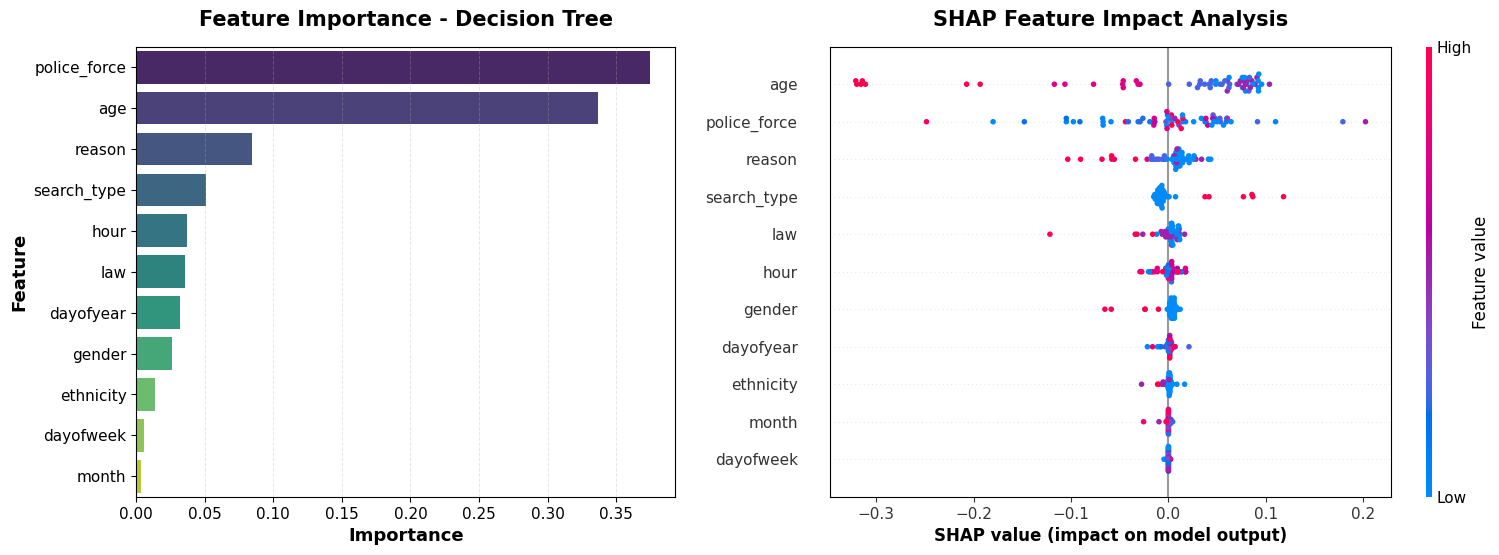

Test data size: 99378



Optimizing threshold based on 'min_recall_difference':
* Evaluating 16 thresholds from 0.5 to 1.0...
* Optimization metric: min_recall_difference


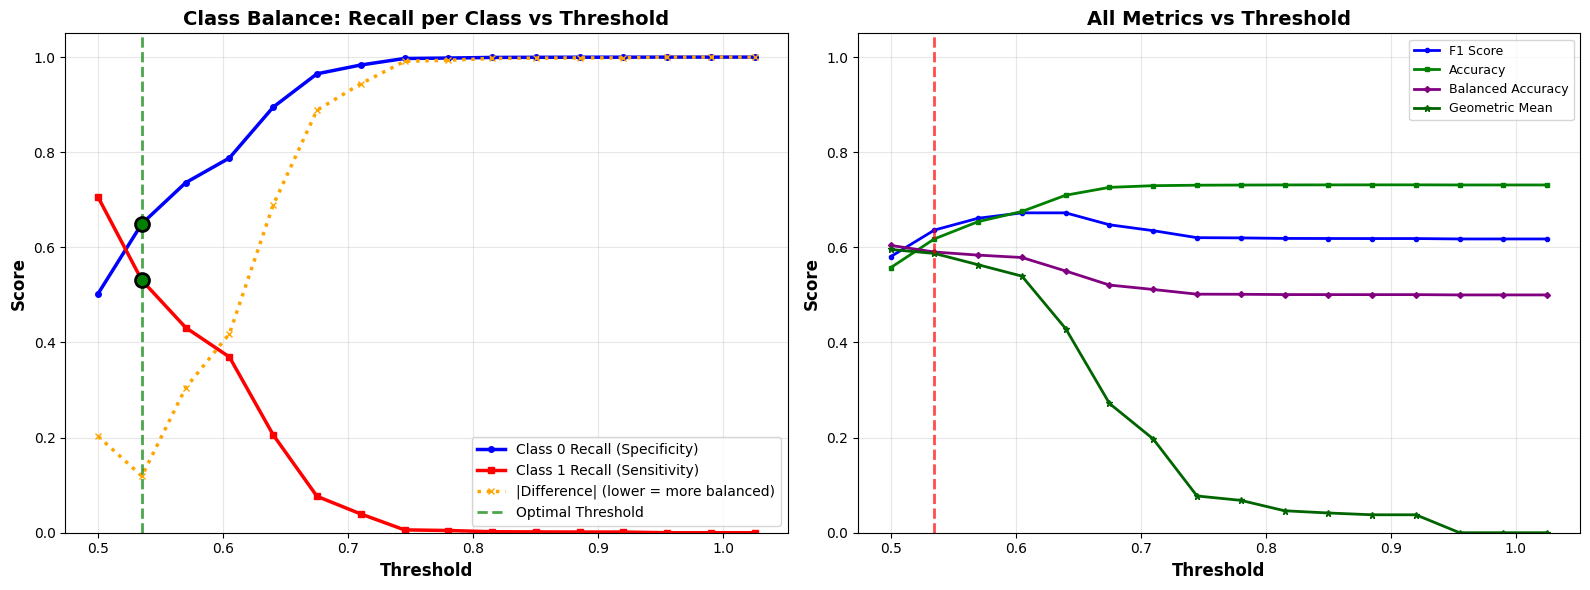


THRESHOLD OPTIMIZATION RESULTS
Optimization Metric: Recall Difference (minimized)
Optimal Threshold:   0.5350
Minimum Recall Difference: 0.1190

ALL METRICS AT OPTIMAL THRESHOLD:
  Accuracy:           0.6178
  Balanced Accuracy:  0.5902
  Geometric Mean:     0.5872
  F1 Score:           0.6363
  Precision: 0.6740
  Recall:    0.6178

  Class 0 Recall (Specificity): 0.6497
  Class 1 Recall (Sensitivity): 0.5308
  Recall Difference:            0.1190



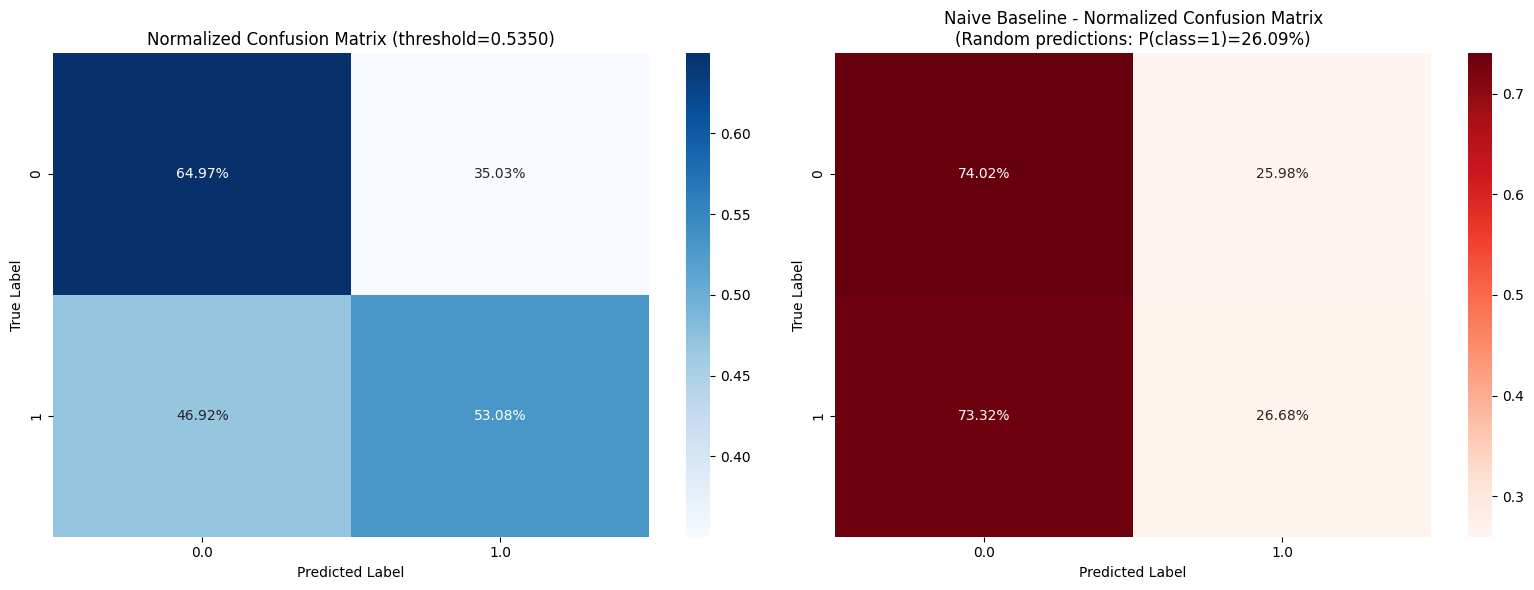


MODEL COMPARISON
Metric               Trained Model   Naive Baseline  Improvement    
------------------------------------------------------------
Accuracy             0.6178          0.6129          0.0049         
Balanced Accuracy    0.5902          0.5035          0.0868         
Geometric Mean       0.5872          0.4443          0.1429         
F1 Score             0.6363          0.6112          0.0251         
Precision            0.6740          0.6096          0.0643         
Recall               0.6178          0.6129          0.0049         
Class 0 Recall       0.6497          0.7402          -0.0904        
Class 1 Recall       0.5308          0.2668          0.2640         
Recall Difference    0.1190          0.4734          -0.3544        
 Unbalance: 261,056 (72.23%) negatives vs 100,373 (27.77%) positives

Starting Pipeline Training...


Pipeline fitting complete. Total time: 11.59 seconds.
Getting a set of 100 samples for the SHAP...


Calculating SHAP values (may take some time)...


  0%|          | 0/71 [00:00<?, ?it/s]

/home/alumno/py313ml/.venv/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


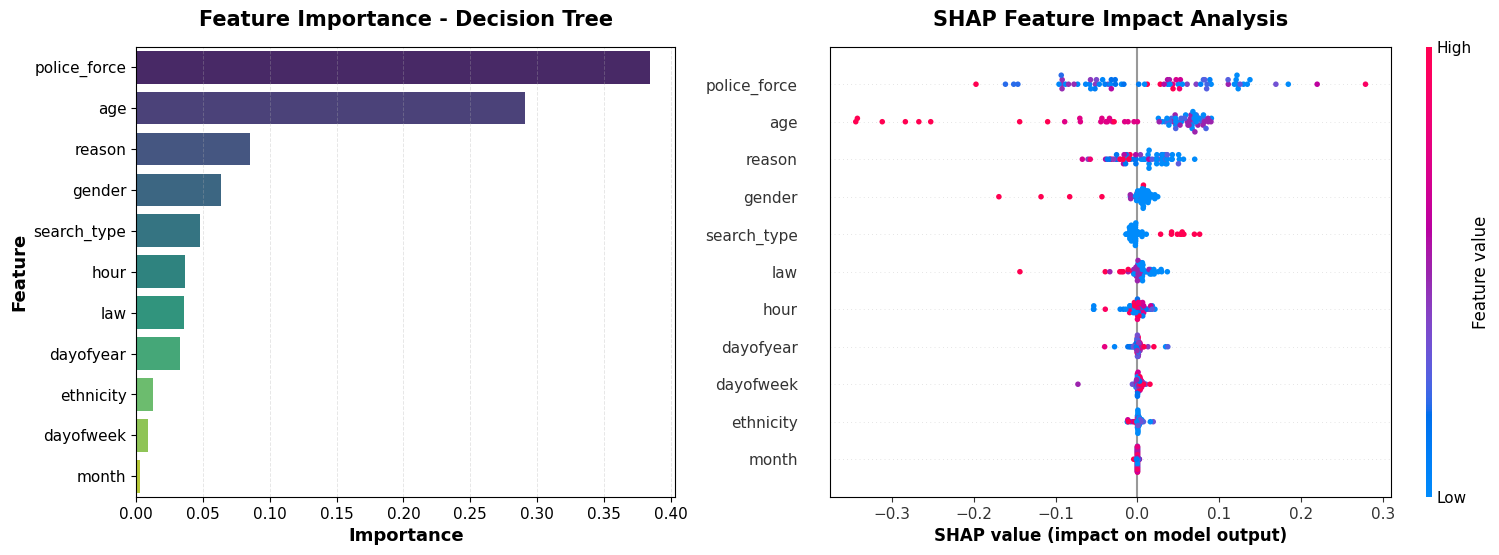

Test data size: 80834



Using provided threshold: 0.535


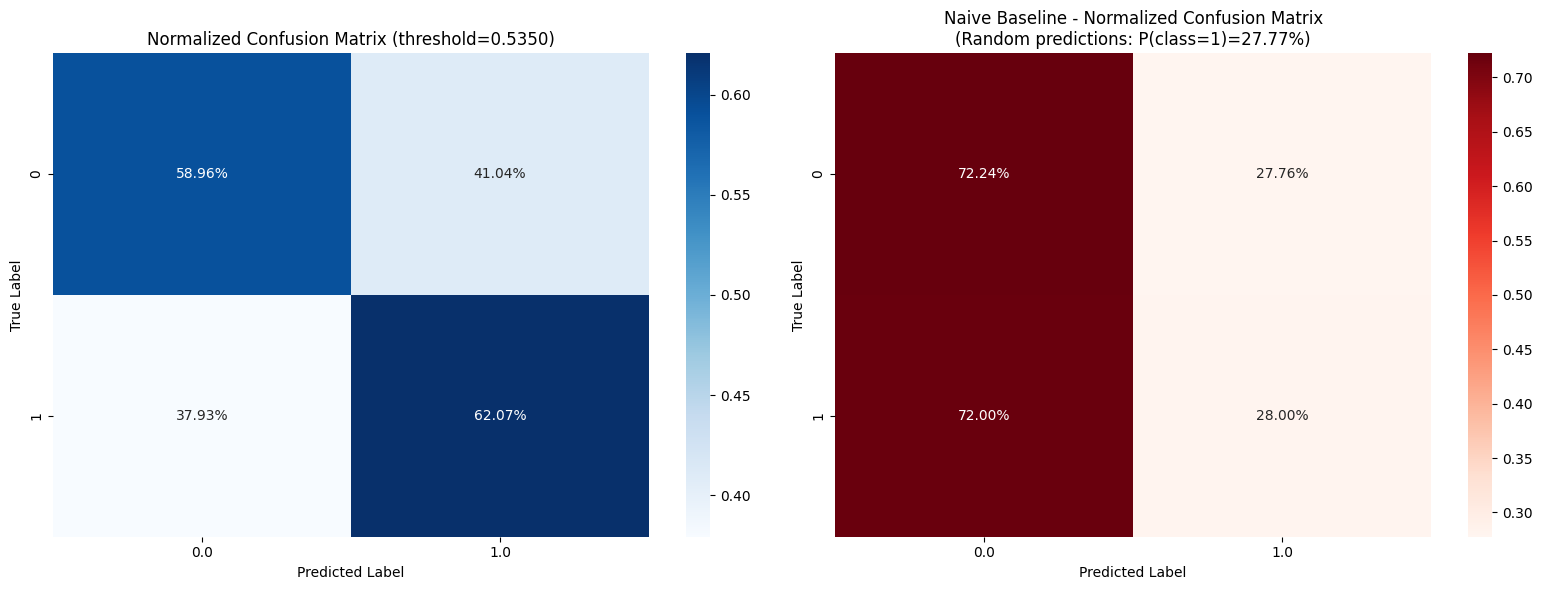


MODEL COMPARISON
Metric               Trained Model   Naive Baseline  Improvement    
------------------------------------------------------------
Accuracy             0.5985          0.5959          0.0027         
Balanced Accuracy    0.6052          0.5012          0.1040         
Geometric Mean       0.6050          0.4498          0.1552         
F1 Score             0.6177          0.5942          0.0235         
Precision            0.6756          0.5926          0.0830         
Recall               0.5985          0.5959          0.0027         
Class 0 Recall       0.5896          0.7224          -0.1327        
Class 1 Recall       0.6207          0.2800          0.3406         
Recall Difference    0.0310          0.4423          -0.4113        
 Unbalance: 229,536 (72.65%) negatives vs 86,410 (27.35%) positives

Starting Pipeline Training...


Pipeline fitting complete. Total time: 11.43 seconds.
Getting a set of 100 samples for the SHAP...


Calculating SHAP values (may take some time)...


  0%|          | 0/71 [00:00<?, ?it/s]

/home/alumno/py313ml/.venv/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


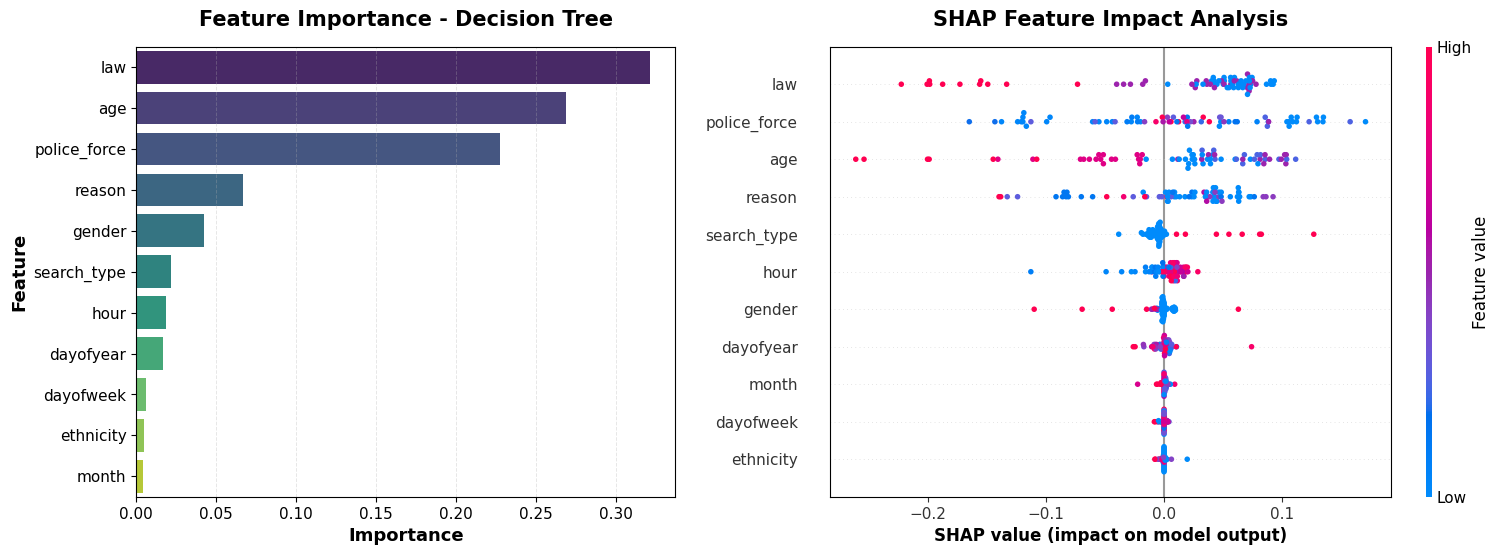

Test data size: 71375



Using provided threshold: 0.535


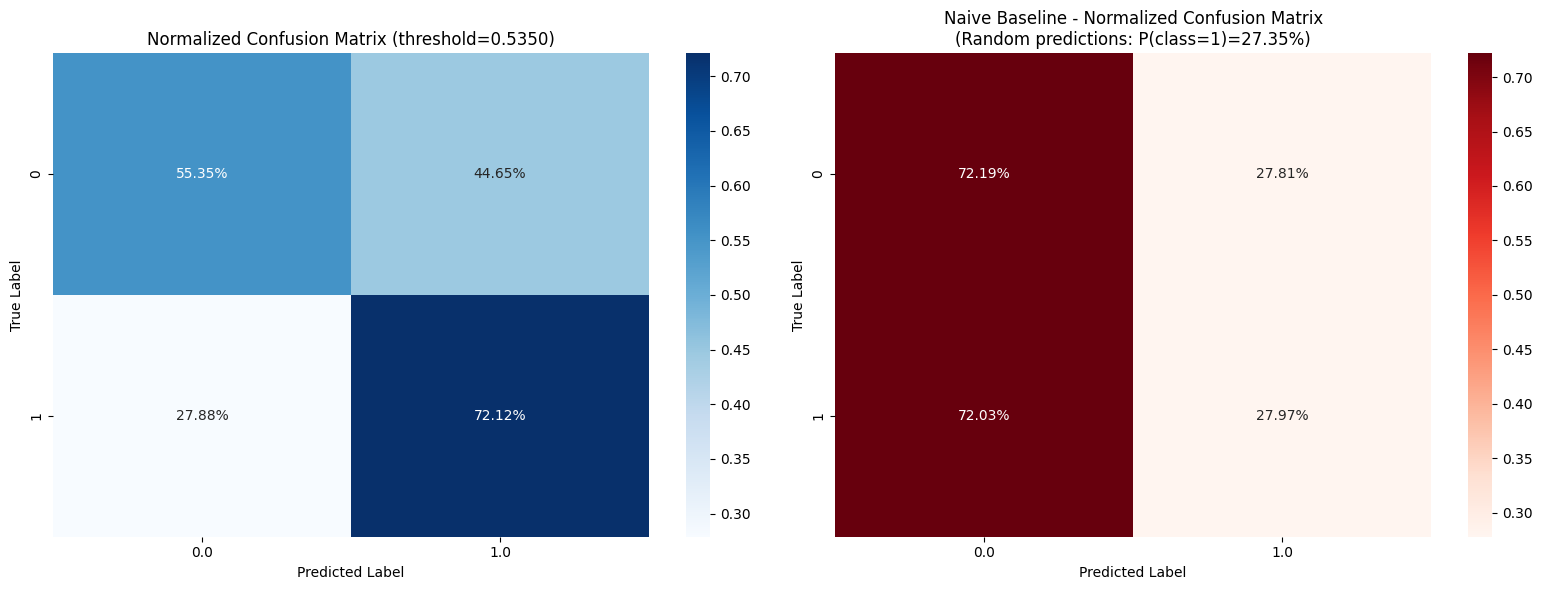


MODEL COMPARISON
Metric               Trained Model   Naive Baseline  Improvement    
------------------------------------------------------------
Accuracy             0.6006          0.5977          0.0029         
Balanced Accuracy    0.6373          0.5008          0.1365         
Geometric Mean       0.6318          0.4494          0.1824         
F1 Score             0.6203          0.5972          0.0231         
Precision            0.7095          0.5967          0.1129         
Recall               0.6006          0.5977          0.0029         
Class 0 Recall       0.5535          0.7219          -0.1685        
Class 1 Recall       0.7212          0.2797          0.4415         
Recall Difference    0.1677          0.4422          -0.2745        


In [8]:
fractions = {
    2022: 0.8,
    2023: 0.8,
    2024: 0.8,
    2025: 0.8
}

# Stratified sampling
train_df = df_final.sampleBy("year", fractions, seed=42)
test_df = df_final.join(train_df, on=df_final.columns, how="left_anti")

best_threshold = None
for year in [2023, 2024, 2025]:
    if year == 2023:
        train_df_objective = (
            train_df.filter(
                F.col("year") <= year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") <= year
            )
        )
    else:
        train_df_objective = (
            train_df.filter(
                F.col("year") == year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") == year
            )
        )

    trained_pipeline, neg_count, pos_count, transformed_df = train_dt(
        train_df_objective,
        categorical_cols, 
        numeric_cols,
        feature_cols
    )
    
    show_importances(
        year=year,
        trained_pipeline=trained_pipeline,
        categorical_cols=categorical_cols,
        numeric_cols=numeric_cols,
        feature_cols=feature_cols,
        transformed_df=transformed_df,
        sample_size=100  
    )
    
    if best_threshold is None:
        predictions, best_threshold = calculate_metrics(
            year = year,
            trained_pipeline = trained_pipeline,
            test_df = test_df_objective,
            neg_count = neg_count,
            pos_count = pos_count,
            threshold = None,
            optimize_threshold=True,
            optimization_metric='min_recall_difference'
        )

    else:
        predictions, best_threshold = calculate_metrics(
            year = year,
            trained_pipeline = trained_pipeline,
            test_df = test_df_objective,
            neg_count = neg_count,
            pos_count = pos_count,
            threshold = best_threshold,
            optimize_threshold=False
        )